<a href="https://colab.research.google.com/github/brianphu2310/COFFEE-EXTRACTION/blob/main/Coffee_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

☕ COFFEE DATA ANALYSIS

📁 STEP 1: Upload your Excel file
   Click 'Choose Files' button below and select your Coffee_Data.xlsx
--------------------------------------------------


Saving Coffee Analysis Dashboard.xlsx to Coffee Analysis Dashboard (5).xlsx

✅ Loaded file: Coffee Analysis Dashboard (5).xlsx
   Rows: 13
   Columns: 15

📊 FIRST 5 ROWS:
      Method  Time_seconds  Caffein_mg_per_L  Volume_ml  Antioxidant_rank  \
0  Ristretto            22              5085         25                 4   
1   Espresso            28              3108         40                 3   
2      Lungo            40              1690        110                 5   
3  AeroPress            90               240        250                 1   
4   Moka Pot           240              2192        250                 3   

  Complexity           Extraction_mechanism         Equipment  Time_Minutes  \
0       High  Pressure (9 bar) - restricted  Espresso Machine      0.366667   
1       High              Pressure (9 bar)   Espresso Machine      0.466667   
2       High    Pressure (9 bar) - extended  Espresso Machine      0.666667   
3        Low           Pressure + Immersion       

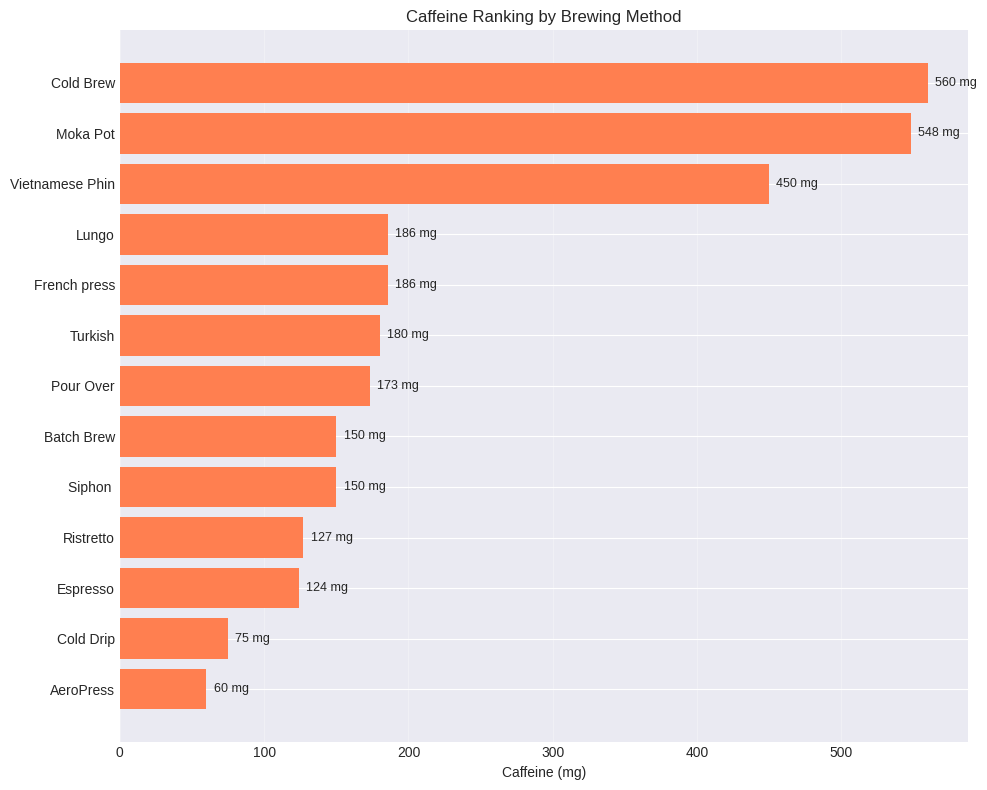

✅ Saved: caffeine_ranking.png

📊 DRAWING CHART 2: Time vs Caffeine...


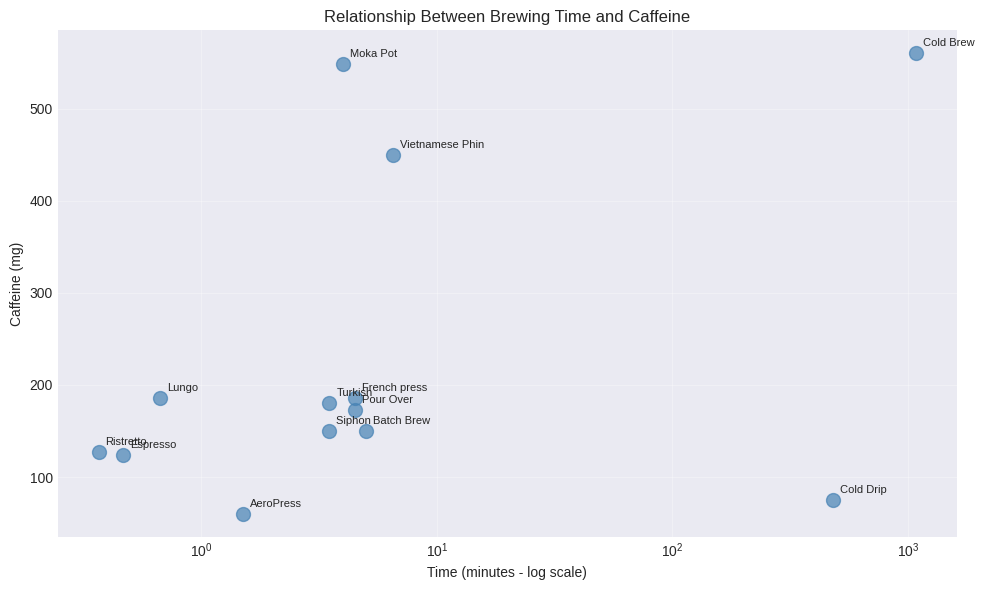

✅ Saved: time_vs_caffeine.png

📊 DRAWING CHART 3: Correlation Heatmap...


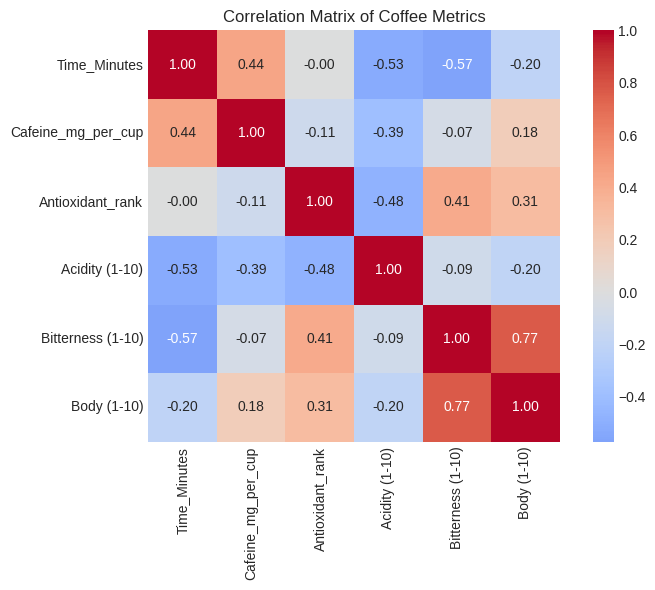

✅ Saved: correlation_heatmap.png

📊 DRAWING CHART 4: Taste Profile Comparison...


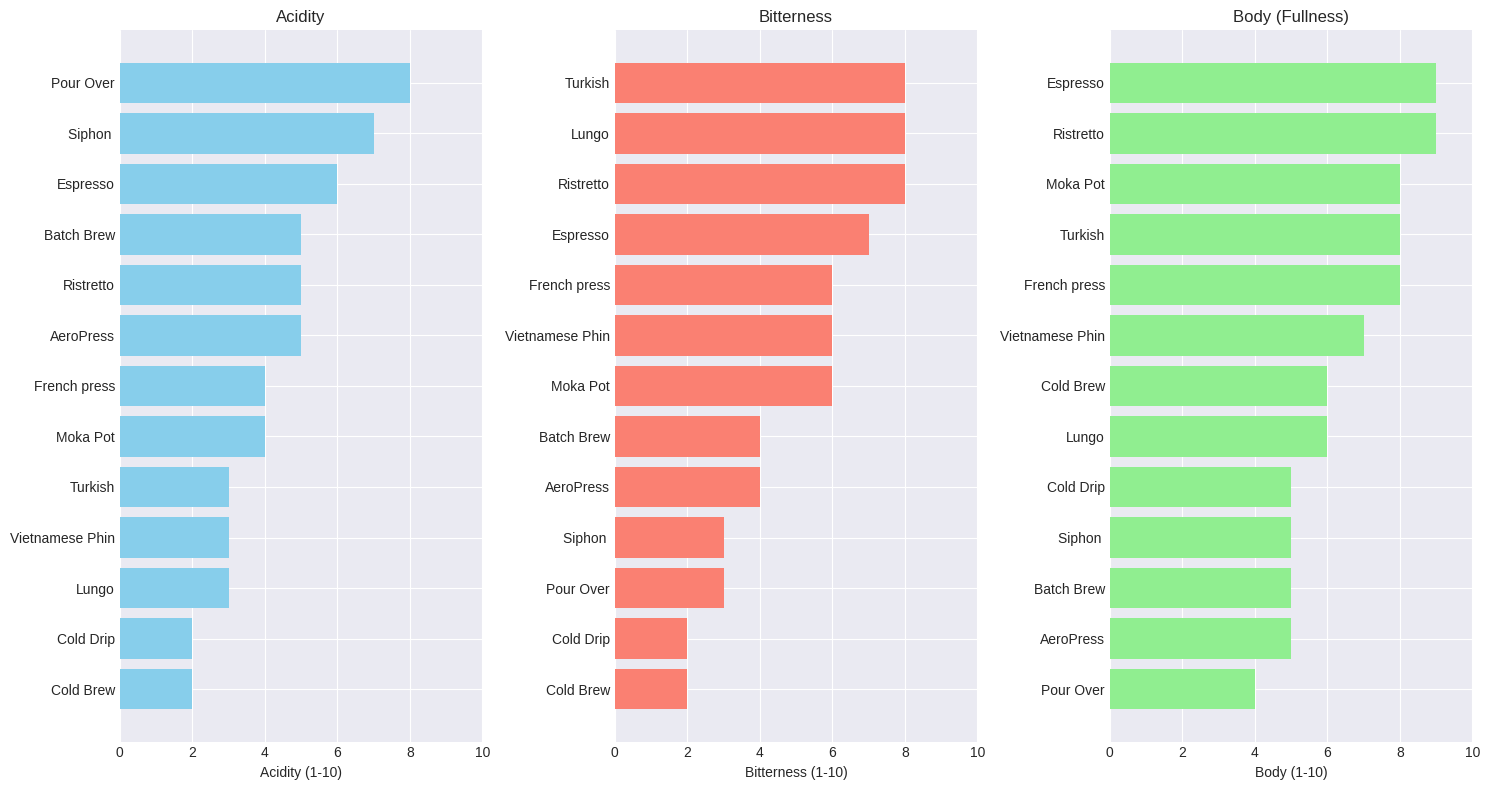

✅ Saved: taste_comparison.png

✅ Saved: coffee_data_clean.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 COMPLETED! Files created:
   - caffeine_ranking.png
   - time_vs_caffeine.png
   - correlation_heatmap.png
   - taste_comparison.png
   - coffee_data_clean.csv

💡 KEY INSIGHTS:
--------------------------------------------------
• Highest Caffeine: Cold Brew (560mg), Moka Pot (548mg)
• Fastest: Ristretto (0.37 min), Espresso (0.47 min)
• Healthiest: AeroPress (Antioxidant rank #1)
• Most Acidic: Pour Over (8/10)
• Most Bitter: Ristretto, Lungo, Turkish (8/10)
• Fullest Body: Ristretto, Espresso (9/10)


In [6]:
# ============================================
# COFFEE DATA ANALYSIS - COMPLETE CODE
# Run everything in one cell
# ============================================

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files

# Set display settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

print("="*50)
print("☕ COFFEE DATA ANALYSIS")
print("="*50)

# 2. Upload file
print("\n📁 STEP 1: Upload your Excel file")
print("   Click 'Choose Files' button below and select your Coffee_Data.xlsx")
print("-"*50)

uploaded = files.upload()

# 3. Read data
file_name = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

print(f"\n✅ Loaded file: {file_name}")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")

# 4. View data
print("\n📊 FIRST 5 ROWS:")
print(df.head())

# 5. Basic statistics
print("\n📊 DESCRIPTIVE STATISTICS:")
print(df.describe())

# 6. CHART 1: Caffeine Ranking
print("\n📊 DRAWING CHART 1: Caffeine Ranking...")
try:
    df_sorted = df.sort_values('Cafeine_mg_per_cup', ascending=True)

    plt.figure(figsize=(10, 8))
    bars = plt.barh(df_sorted['Method'], df_sorted['Cafeine_mg_per_cup'], color='coral')
    plt.xlabel('Caffeine (mg)')
    plt.title('Caffeine Ranking by Brewing Method')
    plt.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, df_sorted['Cafeine_mg_per_cup']):
        plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f} mg', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('caffeine_ranking.png', dpi=150)
    plt.show()
    print("✅ Saved: caffeine_ranking.png")
except Exception as e:
    print(f"ERROR during CHART 1: {e}")
    import traceback
    traceback.print_exc()

# 7. CHART 2: Time vs Caffeine (Log Scale)
print("\n📊 DRAWING CHART 2: Time vs Caffeine...")
try:
    plt.figure(figsize=(10, 6))
    plt.scatter(df['Time_Minutes'], df['Cafeine_mg_per_cup'], s=100, alpha=0.7, c='steelblue')
    for i, row in df.iterrows():
        plt.annotate(row['Method'], (row['Time_Minutes'], row['Cafeine_mg_per_cup']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    plt.xscale('log')
    plt.xlabel('Time (minutes - log scale)')
    plt.ylabel('Caffeine (mg)')
    plt.title('Relationship Between Brewing Time and Caffeine')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('time_vs_caffeine.png', dpi=150)
    plt.show()
    print("✅ Saved: time_vs_caffeine.png")
except Exception as e:
    print(f"ERROR during CHART 2: {e}")
    import traceback
    traceback.print_exc()

# 8. CHART 3: Correlation Heatmap
print("\n📊 DRAWING CHART 3: Correlation Heatmap...")
try:
    corr_columns = ['Time_Minutes', 'Cafeine_mg_per_cup', 'Antioxidant_rank', 'Acidity (1-10)', 'Bitterness (1-10)', 'Body (1-10)']
    corr_matrix = df[corr_columns].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
    plt.title('Correlation Matrix of Coffee Metrics')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=150)
    plt.show()
    print("✅ Saved: correlation_heatmap.png")
except Exception as e:
    print(f"ERROR during CHART 3: {e}")
    import traceback
    traceback.print_exc()

# 9. CHART 4: Taste Profile Comparison
print("\n📊 DRAWING CHART 4: Taste Profile Comparison...")
try:
    fig, axes = plt.subplots(1, 3, figsize=(15, 8))

    # Acidity
    df_sorted_a = df.sort_values('Acidity (1-10)', ascending=True)
    axes[0].barh(df_sorted_a['Method'], df_sorted_a['Acidity (1-10)'], color='skyblue')
    axes[0].set_xlabel('Acidity (1-10)')
    axes[0].set_title('Acidity')
    axes[0].set_xlim(0, 10)

    # Bitterness
    df_sorted_b = df.sort_values('Bitterness (1-10)', ascending=True)
    axes[1].barh(df_sorted_b['Method'], df_sorted_b['Bitterness (1-10)'], color='salmon')
    axes[1].set_xlabel('Bitterness (1-10)')
    axes[1].set_title('Bitterness')
    axes[1].set_xlim(0, 10)

    # Body
    df_sorted_c = df.sort_values('Body (1-10)', ascending=True)
    axes[2].barh(df_sorted_c['Method'], df_sorted_c['Body (1-10)'], color='lightgreen')
    axes[2].set_xlabel('Body (1-10)')
    axes[2].set_title('Body (Fullness)')
    axes[2].set_xlim(0, 10)

    plt.tight_layout()
    plt.savefig('taste_comparison.png', dpi=150)
    plt.show()
    print("✅ Saved: taste_comparison.png")
except Exception as e:
    print(f"ERROR during CHART 4: {e}")
    import traceback
    traceback.print_exc()

# 10. Export clean CSV
try:
    df.to_csv('coffee_data_clean.csv', index=False)
    print("\n✅ Saved: coffee_data_clean.csv")
except Exception as e:
    print(f"ERROR saving CSV: {e}")
    import traceback
    traceback.print_exc()

# 11. Download file to computer
try:
    files.download('coffee_data_clean.csv')
except Exception as e:
    print(f"ERROR downloading CSV: {e}")
    import traceback
    traceback.print_exc()

# 12. Summary
print("\n" + "="*50)
print("🎉 COMPLETED! Files created:")
print("   - caffeine_ranking.png")
print("   - time_vs_caffeine.png")
print("   - correlation_heatmap.png")
print("   - taste_comparison.png")
print("   - coffee_data_clean.csv")
print("="*50)

# 13. Key Insights
print("\n💡 KEY INSIGHTS:")
print("-"*50)
print("• Highest Caffeine: Cold Brew (560mg), Moka Pot (548mg)")
print("• Fastest: Ristretto (0.37 min), Espresso (0.47 min)")
print("• Healthiest: AeroPress (Antioxidant rank #1)")
print("• Most Acidic: Pour Over (8/10)")
print("• Most Bitter: Ristretto, Lungo, Turkish (8/10)")
print("• Fullest Body: Ristretto, Espresso (9/10)")
print("="*50)
